<a href="https://colab.research.google.com/github/syedmahmoodiagents/genai_classes/blob/main/StateGraph_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain-huggingface --q

In [2]:
!pip install langgraph --q

In [3]:
from typing import TypedDict, Literal

from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver

In [4]:
import os

In [5]:
os.environ["HF_TOKEN"] = "hf_zIvXpRihcLDYQxQSByHOzDVeLxVhaQMEg"

In [6]:
llm = ChatHuggingFace(llm = HuggingFaceEndpoint(repo_id="openai/gpt-oss-20b"))

# Routing Condition

In [7]:
class State(TypedDict):
    question: str
    operation: str
    a: int
    b: int
    answer: int


In [9]:
def addition_node(state: State):
    """Add two numbers."""
    result =  state["a"] + state["b"]
    return {"answer": result}


def multiplication_node(state: State):
    """Multiply two numbers."""
    result =  state["a"] * state["b"]
    return {"answer": result}


In [10]:
def agent(state: State):

    question = state["question"]

    response = llm.invoke(
        f"""
        You are a mathematical routing agent.

        Determine which operation the user wants.

        User question:
        {question}

        Respond with ONLY one of these words:

        ADD
        MULTIPLY
        """
    )

    operation = response.content.strip().upper()

    import re
    numbers = re.findall(r"-?\d+", question)

    a = int(numbers[0])
    b = int(numbers[1])

    return {"operation": operation, "a": a, "b": b}


In [11]:
def route_operation(state: State):

    if state["operation"] == "ADD":
        return "doadd"

    elif state["operation"] == "MULTIPLY":
        return "domultiply"

In [12]:

builder = StateGraph(State)
builder.add_node("agent", agent)
builder.add_node("addition", addition_node)
builder.add_node("multiplication", multiplication_node)

builder.set_entry_point("agent")
# Conditional routing
builder.add_conditional_edges("agent", route_operation, { "doadd": "addition", "domultiply": "multiplication"})

builder.add_edge("addition", END)
builder.add_edge("multiplication", END)




In [13]:
agent_pipeline = builder.compile(checkpointer=InMemorySaver())

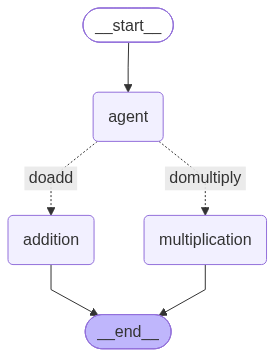

In [14]:
agent_pipeline

In [15]:
config = {"configurable": {"thread_id": "user-1"}}

In [16]:
result1 = agent_pipeline.invoke({"question": "What is 25 plus 15?"},config=config)
print(result1)

{'question': 'What is 25 plus 15?', 'operation': 'ADD', 'a': 25, 'b': 15, 'answer': 40}


In [17]:
result2 = agent_pipeline.invoke({"question": "What is 25 multiplied by 15?"},config=config)
print(result2)

{'question': 'What is 25 multiplied by 15?', 'operation': 'MULTIPLY', 'a': 25, 'b': 15, 'answer': 375}


In [18]:
# import re
# re.findall(r"-?\d+", "there are 70 fruits and 40 vegetables")

# ['70', '40'] as output

# Multiplying the result from memory by 10

In [27]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver


In [28]:
class NewState(TypedDict):
    question: str
    operation: str
    a: int
    b: int
    answer: int


In [36]:
def agentf(sta: NewState):
    question = sta["question"]
    previous_answer = sta.get("answer")

    if previous_answer is not None:

        context = f"""
        Previous calculation result: {previous_answer}

        The user may be referring to this previous result.
        """
    else:

        context = """There is no previous calculation result."""


    response = llm.invoke(
        f"""
        You are a mathematical routing agent.

        {context}

        Current user question:
        {question}

        Determine which operation the user wants.

        Respond with ONLY one of:

        ADD
        MULTIPLY
        """
    )

    operation = response.content.strip().upper()

    import re
    numbers = re.findall(r"-?\d+", question)

    if operation == "MULTIPLY" and previous_answer is not None:

        a = previous_answer
        b = int(numbers[0])

    else:

        a = int(numbers[0])
        b = int(numbers[1])

    return {"operation": operation, "a": a, "b": b}


In [37]:

def add_node(st: NewState):
    """Add two numbers."""
    result = st["a"] + st["b"]
    return {"answer": result}


def multiply_node(stat: NewState):
    """Multiply two numbers."""
    result = stat["a"] * stat["b"]
    return {"answer": result}


def route_operation(str: NewState):

    if str["operation"] == "ADD":
        return "do_add"

    elif str["operation"] == "MULTIPLY":
        return "do_multiply"


In [38]:
build = StateGraph(NewState)

build.add_node("agent", agentf)
build.add_node("adder", add_node)
build.add_node("multiplier", multiply_node)

build.set_entry_point("agent")
build.add_conditional_edges(
    "agent", route_operation, {"do_add": "adder", "do_multiply": "multiplier"}
)
build.add_edge("adder", END)
build.add_edge("multiplier", END)
agent_pipe = build.compile(checkpointer=InMemorySaver())


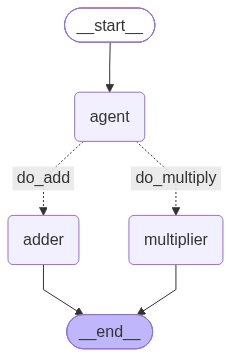

In [39]:
agent_pipe

In [43]:
conf = {"configurable": {"thread_id": "new1"}}

In [44]:

result1 = agent_pipe.invoke({"question": "What is 25 plus 15?"},config=conf)
print(result1)

{'question': 'What is 25 plus 15?', 'operation': 'ADD', 'a': 25, 'b': 15, 'answer': 40}


In [45]:
result2 = agent_pipe.invoke({"question": "Multiply the result by 10"}, config=conf)
print(result2)

{'question': 'Multiply the result by 10', 'operation': 'MULTIPLY', 'a': 40, 'b': 10, 'answer': 400}
